# End-to-End Sales Forecasting & Demand Intelligence System

## Internship Final Project (Week 3 & Week 4)

### Submitted By
**Gajanand**

---

## Objective

The objective of this project is to build an end-to-end sales forecasting and demand intelligence system that helps businesses predict future sales, identify unusual sales patterns, segment products based on demand behavior, and provide interactive business insights through a Streamlit dashboard.

This project covers:
- Data Cleaning & Exploration
- Time Series Analysis
- Sales Forecasting (SARIMA, Prophet & XGBoost)
- Anomaly Detection
- Product Demand Segmentation
- Interactive Dashboard Development
- Executive Business Reporting

# 1. Import Required Libraries

Before analyzing the dataset, we need to import the Python libraries required for data manipulation, visualization, time series analysis, machine learning, forecasting, anomaly detection, clustering, and dashboard development.

Each library serves a specific purpose, and understanding why we use them is an important part of becoming a Data Scientist.

In [3]:
# ==========================
# Data Handling Libraries
# ==========================

import pandas as pd
import numpy as np

# 2. Business Problem

## Problem Statement

Retail and e-commerce companies need to accurately predict future product demand to maintain the right inventory levels.

Incorrect demand forecasting can lead to:

- Overstocking, resulting in increased storage costs and blocked capital.
- Understocking, leading to lost sales and dissatisfied customers.

The objective of this project is to develop an intelligent sales forecasting and demand intelligence system that can:

- Forecast future sales using multiple forecasting techniques.
- Detect unusual sales patterns and anomalies.
- Segment products based on demand behavior.
- Provide business insights through an interactive Streamlit dashboard.
- Support better inventory planning and business decision-making.

# 3. Project Workflow

This project follows a complete end-to-end Data Science lifecycle.

### Workflow

1. Business Understanding
2. Data Collection
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Time Series Analysis
7. Forecasting Model Development
8. Model Evaluation
9. Anomaly Detection
10. Product Segmentation
11. Dashboard Development
12. Business Report

# 6. Dataset Description

## Superstore Sales Dataset

The primary dataset used in this project is the Superstore Sales dataset.

It contains historical retail sales transactions collected over four years.

The dataset includes information about:

- Orders
- Customers
- Products
- Categories
- Regions
- Sales
- Profit
- Shipping
- Dates

This dataset will be used for:

- Exploratory Data Analysis (EDA)
- Time Series Analysis
- Sales Forecasting
- Product Demand Analysis
- Business Intelligence

In [4]:
# ===========================================
# Import Required Libraries
# ===========================================

import pandas as pd
import numpy as np

In [5]:
# ===========================================
# Load Superstore Dataset
# ===========================================

df = pd.read_csv("../data/train.csv")

# 7. Load the Dataset

The dataset is loaded into a Pandas DataFrame. Before performing any analysis, it is important to inspect the structure, dimensions, column names, and data types to ensure the data has been loaded correctly.

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [8]:
df.shape

(9800, 18)

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [11]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


# 8. Convert Date Columns

The `Order Date` and `Ship Date` columns are initially stored as text. To perform time-series analysis and extract meaningful date-based features, these columns are converted into the `datetime` format.

In [12]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    str
Ship Date     str
dtype: object

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [14]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

# 9. Feature Engineering

Feature engineering is the process of creating meaningful variables from existing data.

In this project, additional time-based features are extracted from the **Order Date** column to support exploratory analysis, forecasting, seasonality detection, and machine learning models.

The following features will be created:

- Year
- Month
- Week Number
- Day of Week
- Quarter
- Season

In [15]:
# ==========================================
# Extract Year from Order Date
# ==========================================

df["Year"] = df["Order Date"].dt.year

In [16]:
df[["Order Date", "Year"]].head()

,Order Date,Year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


## Extract Month

The Month feature is extracted from the **Order Date** column to analyze monthly sales trends, identify seasonality, and support forecasting models.

In [17]:
# ==========================================
# Extract Month from Order Date
# ==========================================

df["Month"] = df["Order Date"].dt.month

In [18]:
df[["Order Date", "Year", "Month"]].head()

,Order Date,Year,Month
0,2017-11-08,2017,11
1,2017-11-08,2017,11
2,2017-06-12,2017,6
3,2016-10-11,2016,10
4,2016-10-11,2016,10


## Extract Week Number

The Week Number feature is extracted from the **Order Date** column to support weekly trend analysis, inventory planning, demand forecasting, and anomaly detection.

In [19]:
# ==========================================
# Extract Week Number
# ==========================================

df["Week"] = df["Order Date"].dt.isocalendar().week

In [20]:
df[["Order Date","Week"]].head()

,Order Date,Week
0,2017-11-08,45
1,2017-11-08,45
2,2017-06-12,24
3,2016-10-11,41
4,2016-10-11,41


## Extract Day of Week

The Day of Week feature helps analyze customer purchasing behavior across different weekdays and supports demand pattern analysis.

In [21]:
# ==========================================
# Extract Day Name
# ==========================================

df["Day Name"] = df["Order Date"].dt.day_name()

In [22]:
df[["Order Date","Day Name"]].head()

,Order Date,Day Name
0,2017-11-08,Wednesday
1,2017-11-08,Wednesday
2,2017-06-12,Monday
3,2016-10-11,Tuesday
4,2016-10-11,Tuesday


## Extract Quarter

Quarter information is useful for quarterly business reporting, financial analysis, and long-term sales trend evaluation.

In [23]:
# ==========================================
# Extract Quarter
# ==========================================

df["Quarter"] = df["Order Date"].dt.quarter

In [24]:
df[["Order Date","Quarter"]].head()

,Order Date,Quarter
0,2017-11-08,4
1,2017-11-08,4
2,2017-06-12,2
3,2016-10-11,4
4,2016-10-11,4


## Extract Season

Season is derived from the Month feature to analyze seasonal demand patterns. This helps identify how sales vary across different seasons and supports long-term business planning.

In [25]:
# ==========================================
# Function to Map Month to Season
# ==========================================

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

In [26]:
# ==========================================
# Create Season Feature
# ==========================================

df["Season"] = df["Month"].apply(get_season)

In [27]:
df[["Order Date", "Month", "Season"]].head(10)

,Order Date,Month,Season
0,2017-11-08,11,Autumn
1,2017-11-08,11,Autumn
2,2017-06-12,6,Summer
3,2016-10-11,10,Autumn
4,2016-10-11,10,Autumn
5,2015-06-09,6,Summer
6,2015-06-09,6,Summer
7,2015-06-09,6,Summer
8,2015-06-09,6,Summer
9,2015-06-09,6,Summer


# 10. Data Quality Assessment

Before performing exploratory data analysis and forecasting, it is important to assess the quality of the dataset.

The following checks are performed:

- Missing Values
- Duplicate Records
- Data Types
- Data Consistency

These checks help ensure the dataset is reliable for further analysis.

In [28]:
# ==========================================
# Check Missing Values
# ==========================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Postal Code    11
dtype: int64

## Duplicate Record Check

Duplicate records may result from repeated transactions or data entry errors. Identifying duplicates helps prevent biased analysis and inaccurate model training.

In [29]:
# ==========================================
# Check Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicates}")

Number of Duplicate Rows: 0


## Data Type Validation

The data types of each column are reviewed to ensure that numerical, categorical, and datetime columns are correctly identified for further analysis.

In [30]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
Day Name                    str
Quarter                   int32
Season                      str
dtype: object

# 11. Time Series Data Preparation

The original dataset contains multiple transactions for each day.

For time-series forecasting, the data must be aggregated into daily, weekly, and monthly sales totals.

These aggregated datasets will be used for forecasting models such as SARIMA, Prophet, and XGBoost.

In [31]:
# ==========================================
# Daily Sales Aggregation
# ==========================================

daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [32]:
# ==========================================
# Weekly Sales Aggregation
# ==========================================

weekly_sales = (
    df.resample("W", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [33]:
monthly_sales = (
    df.resample("ME", on="Order Date")["Sales"]
      .sum()
      .reset_index()
)
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [34]:
daily_sales.shape

(1230, 2)

In [35]:
weekly_sales.shape

(209, 2)

In [36]:
monthly_sales.shape

(48, 2)

# 12. Validate Aggregated Time Series

Before performing visualization and forecasting, the aggregated datasets are validated to ensure that the number of observations and sales totals are consistent with the original dataset.

In [37]:
print("Original Dataset Shape :", df.shape)

print("Daily Sales Shape :", daily_sales.shape)

print("Weekly Sales Shape :", weekly_sales.shape)

print("Monthly Sales Shape :", monthly_sales.shape)

Original Dataset Shape : (9800, 24)
Daily Sales Shape : (1230, 2)
Weekly Sales Shape : (209, 2)
Monthly Sales Shape : (48, 2)


In [38]:
print("Original Sales Total")
print(df["Sales"].sum())

print()

print("Daily Sales Total")
print(daily_sales["Sales"].sum())

print()

print("Weekly Sales Total")
print(weekly_sales["Sales"].sum())

print()

print("Monthly Sales Total")
print(monthly_sales["Sales"].sum())

Original Sales Total
2261536.7827

Daily Sales Total
2261536.7827

Weekly Sales Total
2261536.7827

Monthly Sales Total
2261536.7827


# 13. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand sales patterns, identify important business trends, and answer key business questions before building forecasting models.

The first business question is:

**Which product category generates the highest total sales revenue?**

In [39]:
# ==========================================
# Total Sales by Category
# ==========================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


### Sales by Product Category

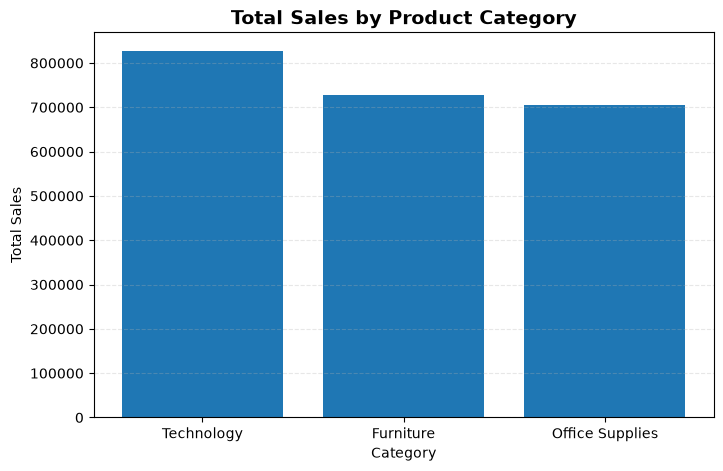

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    category_sales["Category"],
    category_sales["Sales"]
)

plt.title("Total Sales by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Save chart
plt.savefig(
    "../charts/01_total_sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Technology category generated the highest total sales, contributing approximately **$836K** in revenue. Furniture ranked second with around **$742K**, followed closely by Office Supplies with approximately **$719K**. Although all three categories performed well, Technology consistently outperformed the other categories, indicating stronger customer demand and higher revenue generation.

### Business Insight

Technology products are the primary revenue drivers for the business. The company should prioritize inventory planning, marketing campaigns, and product availability for this category to maximize revenue. Furniture and Office Supplies also contribute significantly and should be supported through targeted promotions and seasonal sales strategies.

### Recommendation

- Increase inventory levels for Technology products to avoid stock shortages.
- Launch targeted promotional campaigns for Furniture and Office Supplies to improve their sales contribution.
- Continuously monitor category-wise sales trends to optimize inventory allocation and marketing investments.

## Business Question 2

### Which Region Generates the Highest Total Sales?

This analysis identifies the contribution of each region to total sales. Understanding regional performance helps businesses optimize inventory distribution, marketing investments, and sales strategies.

In [41]:
# ==========================================
# Total Sales by Region
# ==========================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_sales

,Region,Sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


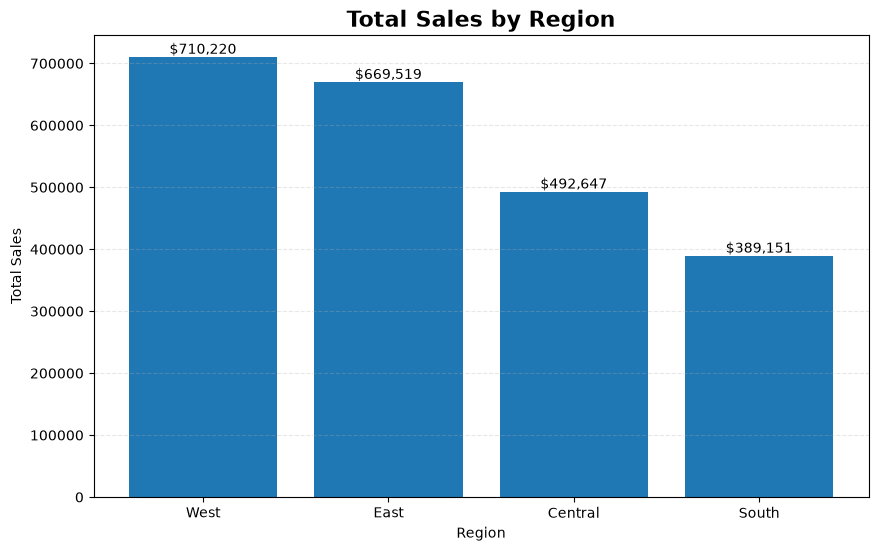

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(
    region_sales["Region"],
    region_sales["Sales"]
)

plt.title(
    "Total Sales by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.savefig(
    "../charts/02_total_sales_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The **West** region generated the highest total sales, contributing approximately **$710,220**, followed closely by the **East** region with **$669,519**. The **Central** region recorded moderate sales of **$492,647**, while the **South** region generated the lowest total sales at **$389,151**. The noticeable variation in sales across regions indicates differences in customer demand, market penetration, and business performance.

### Business Insight

The strong performance of the West and East regions suggests higher customer demand and effective sales operations in these markets. These regions should continue to receive priority in inventory allocation, marketing investments, and customer engagement strategies. The comparatively lower sales in the Central and South regions indicate opportunities for business expansion through targeted promotional campaigns, improved product availability, and region-specific marketing initiatives.

### Recommendation

- Maintain adequate inventory levels in the West and East regions to meet consistently high customer demand.
- Investigate the factors contributing to lower sales in the South region, such as customer preferences, competition, or product availability.
- Develop region-specific marketing campaigns and promotional offers to improve sales performance in the Central and South regions.
- Continuously monitor regional sales trends to support data-driven inventory and resource allocation decisions.

## Business Question 3

### How Have Monthly Sales Changed Over Time?

Monthly sales trend analysis helps identify business growth, seasonal patterns, and periods of high or low demand. This analysis serves as the foundation for time-series forecasting models.

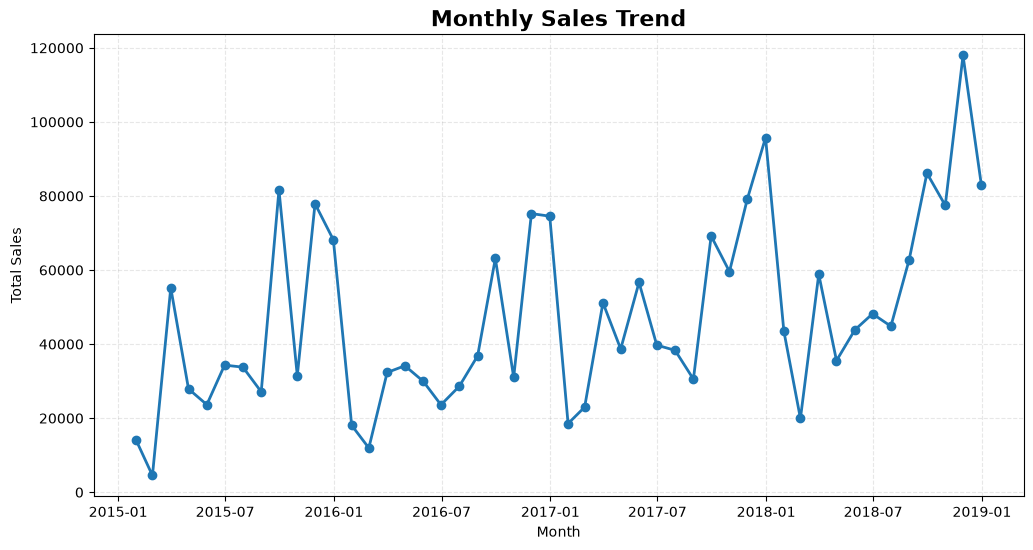

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig(
    "../charts/03_monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The monthly sales trend shows noticeable fluctuations throughout the four-year period, indicating that sales vary significantly from month to month. Although there are occasional declines, the overall trend suggests gradual business growth, with the highest monthly sales recorded towards the end of 2018. Several recurring peaks and troughs indicate the presence of seasonal demand patterns, making the dataset suitable for time-series forecasting.

### Business Insight

The increasing sales trend towards the later years reflects positive business growth and expanding customer demand. However, the recurring fluctuations suggest that sales are influenced by seasonal factors such as holidays, promotional campaigns, or purchasing behavior. Understanding these seasonal patterns will help the business optimize inventory planning, staffing, and marketing activities during high-demand periods.

### Recommendation

- Prepare additional inventory before expected peak sales periods to avoid stock shortages.
- Investigate the causes of recurring sales declines and develop strategies to improve performance during low-demand months.
- Incorporate seasonal trends into forecasting models such as SARIMA, Prophet, and XGBoost to improve prediction accuracy.
- Align promotional campaigns with historically high-demand periods to maximize revenue.

In [44]:
# ==========================================
# Average Sales by Month
# ==========================================

monthly_pattern = (
    df.groupby("Month")["Sales"]
      .sum()
      .reset_index()
)

monthly_pattern

,Month,Sales
0,1,94291.6296
1,2,59371.1154
2,3,197573.5872
3,4,136283.0006
4,5,154086.7237
5,6,145837.5233
6,7,145535.6890
7,8,157315.9270
8,9,300103.4117
9,10,199496.2947


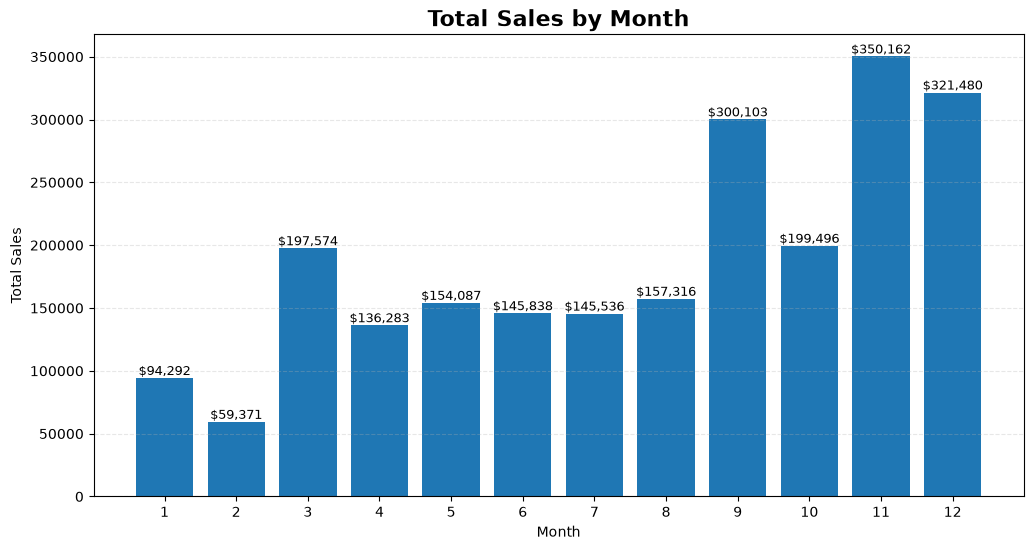

In [45]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_pattern["Month"],
    monthly_pattern["Sales"]
)

plt.title(
    "Total Sales by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1,13))

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.savefig(
    "../charts/04_total_sales_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Monthly sales exhibit noticeable variation throughout the year, indicating the presence of seasonal demand patterns. **November** recorded the highest total sales at approximately **$350,162**, followed by **December** with **$321,480** and **September** with **$300,103**. In contrast, **February** generated the lowest sales at approximately **$59,371**, while **January** also recorded comparatively lower sales. These recurring peaks and troughs suggest that customer purchasing behavior changes significantly across different months.

### Business Insight

The significant increase in sales during September, November, and December suggests strong seasonal demand, likely influenced by festive shopping, year-end purchasing, promotional campaigns, or holiday sales. Conversely, lower sales during January and February indicate periods of reduced customer activity. Understanding these seasonal trends enables the business to optimize inventory planning, staffing, and marketing efforts throughout the year.

### Recommendation

- Increase inventory levels before September, November, and December to meet anticipated customer demand.
- Plan major promotional campaigns during peak sales months to maximize revenue.
- Introduce discounts, loyalty programs, or targeted marketing initiatives during January and February to improve sales performance during low-demand periods.
- Incorporate seasonal effects into forecasting models such as SARIMA and Prophet to improve prediction accuracy.

## Business Question 5

### What is the Average Shipping Time by Region?

Shipping duration is calculated as the difference between the shipping date and the order date. This analysis helps evaluate operational efficiency across different regions.

In [46]:
# ==========================================
# Calculate Shipping Duration
# ==========================================

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [47]:
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
      .reset_index()
)

shipping_region

,Region,Shipping Days
0,East,3.910233
1,West,3.930255
2,South,3.961202
3,Central,4.065876


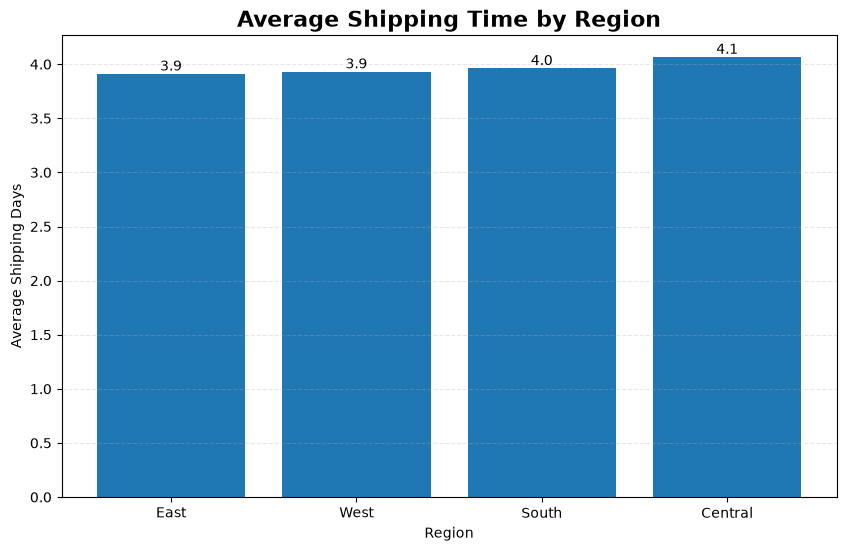

In [48]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    shipping_region["Region"],
    shipping_region["Shipping Days"]
)

plt.title(
    "Average Shipping Time by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.savefig(
    "../charts/05_average_shipping_time_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The average shipping time is relatively consistent across all regions, ranging from approximately **3.9 to 4.1 days**. The **Central** region recorded the longest average shipping time (**4.1 days**), while the **East** and **West** regions had the shortest average shipping duration (**3.9 days**). The small variation indicates that the company's shipping operations are generally consistent across all regions.

### Business Insight

The minimal variation in shipping time suggests that the company's logistics network is operating efficiently across all regions. However, the slightly longer delivery time in the Central region may indicate opportunities to optimize warehouse locations, shipping routes, or logistics partnerships to further improve delivery performance and customer satisfaction.

### Recommendation

- Investigate the operational factors contributing to the slightly longer shipping time in the Central region.
- Continue monitoring shipping performance regularly to maintain consistent service quality across all regions.
- Optimize logistics routes and warehouse distribution if shipping delays increase over time.
- Include shipping performance as a key operational KPI alongside sales and profit metrics.

## Business Question 6

### Which Customer Segment Generates the Highest Sales?

Customer segmentation analysis helps identify the most valuable customer groups based on their total sales contribution. These insights support targeted marketing, customer retention, and business growth strategies.

In [49]:
# ==========================================
# Total Sales by Customer Segment
# ==========================================

segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

segment_sales

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


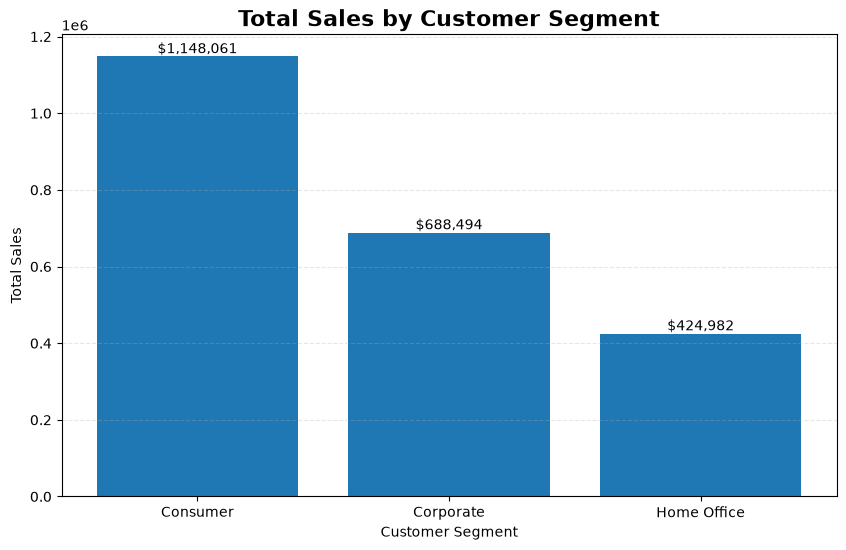

In [50]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    segment_sales["Segment"],
    segment_sales["Sales"]
)

plt.title(
    "Total Sales by Customer Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.savefig(
    "../charts/06_total_sales_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The **Consumer** segment generated the highest total sales, contributing approximately **$1.15 million**, which accounts for nearly half of the overall sales revenue. The **Corporate** segment ranked second with approximately **$688,494**, while the **Home Office** segment generated the lowest sales at approximately **$424,982**. This indicates that Consumer customers represent the largest revenue-generating customer group.

### Business Insight

The Consumer segment is the primary driver of business revenue, indicating strong purchasing activity and a larger customer base. While the Corporate segment also contributes significantly, the Home Office segment presents an opportunity for business expansion through targeted marketing campaigns, customized product offerings, and customer engagement strategies.

### Recommendation

- Continue investing in marketing campaigns targeted at Consumer customers to sustain revenue growth.
- Develop loyalty programs and personalized offers for Corporate customers to increase repeat purchases.
- Design specialized promotional campaigns for the Home Office segment to improve customer acquisition and sales performance.
- Regularly monitor customer segment performance to optimize marketing budgets and inventory planning.

## Business Question 7

### Which Products Generate the Highest Sales?

This analysis identifies the top-performing products based on total sales. Understanding product-level performance helps businesses optimize inventory, prioritize high-demand products, and develop effective marketing strategies.

In [51]:
# ==========================================
# Top 10 Products by Sales
# ==========================================

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


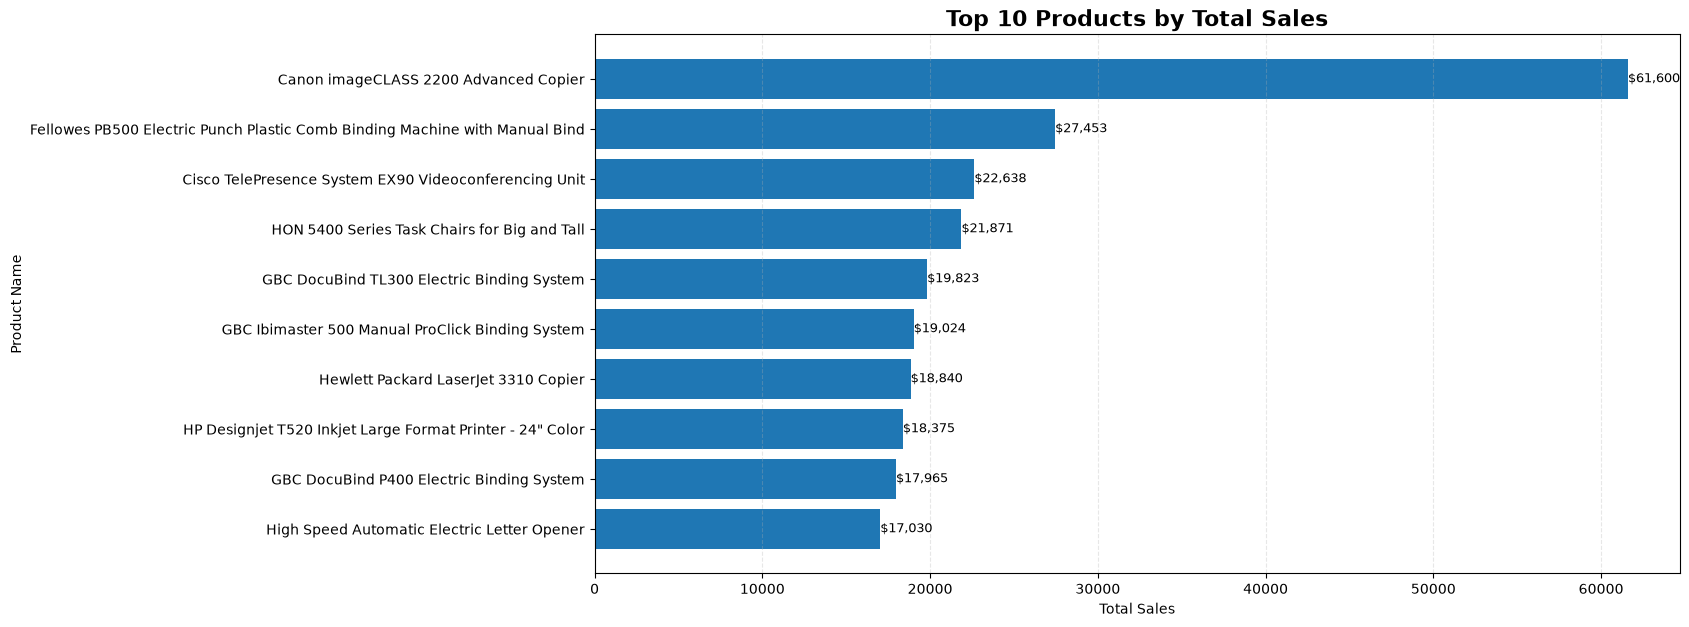

In [52]:
plt.figure(figsize=(14,7))

bars = plt.barh(
    top_products["Product Name"],
    top_products["Sales"]
)

plt.title(
    "Top 10 Products by Total Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9
    )

plt.gca().invert_yaxis()

plt.savefig(
    "../charts/07_top_10_products_by_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The **Canon imageCLASS 2200 Advanced Copier** generated the highest total sales, contributing approximately **$61,600**, which is significantly higher than all other products. The second highest-selling product, **Fellowes PB500 Electric Punch Plastic Comb Binding Machine**, generated approximately **$27,453**, less than half of the sales of the top product. The remaining products generated sales between **$17,000 and $23,000**, indicating a highly skewed sales distribution where a small number of premium products contribute disproportionately to total revenue.

### Business Insight

The sales distribution indicates that a few premium products contribute a significant portion of overall revenue. High-value office equipment and business machines dominate the top-selling products, suggesting strong demand from enterprise and corporate customers. These products should be considered strategic assets for revenue generation and should receive priority in inventory management and promotional planning.

### Recommendation

- Maintain sufficient inventory for high-performing products to prevent stock shortages.
- Prioritize premium products in marketing campaigns and promotional materials.
- Analyze customer purchasing behavior for these products to identify cross-selling and upselling opportunities.
- Regularly monitor product performance to identify emerging best-selling products and changing customer preferences.

# 14. Correlation Analysis

Correlation analysis measures the strength of the relationship between numerical variables.

It helps identify which features have stronger associations with sales and provides useful insights for feature selection in forecasting models.

In [53]:
# ==========================================
# Correlation Matrix
# ==========================================

numerical_columns = [
    "Sales",
    "Shipping Days",
    "Year",
    "Month",
    "Week",
    "Quarter"
]

correlation = df[numerical_columns].corr()

correlation

,Sales,Shipping Days,Year,Month,Week,Quarter
Sales,1.000000,-0.005712,-0.010624,-0.000134,0.000832,-0.001434
Shipping Days,-0.005712,1.000000,-0.024498,0.000210,0.003982,0.004716
Year,-0.010624,-0.024498,1.000000,-0.018278,-0.030788,-0.018515
Month,-0.000134,0.000210,-0.018278,1.000000,0.988067,0.969299
Week,0.000832,0.003982,-0.030788,0.988067,1.000000,0.959314
Quarter,-0.001434,0.004716,-0.018515,0.969299,0.959314,1.000000


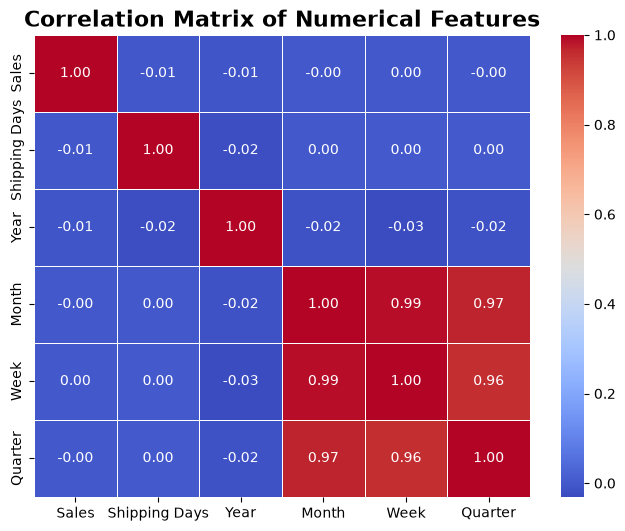

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "../charts/08_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The correlation analysis shows that **Month, Week, and Quarter** are highly positively correlated with each other, with correlation coefficients ranging from **0.96 to 0.99**. This is expected because these features are derived from the same date information. In contrast, **Sales** and **Shipping Days** exhibit very weak correlations with the other numerical variables, indicating that sales are not strongly influenced by these individual time-based features alone.

### Business Insight

The strong relationship among Month, Week, and Quarter confirms that these variables capture similar seasonal information. However, the weak correlation between Sales and the engineered time features suggests that sales patterns are influenced by multiple factors, such as customer behavior, product demand, promotions, and seasonal events, rather than a single time-based variable.

### Recommendation

- Use advanced forecasting models such as **SARIMA**, **Prophet**, and **XGBoost** to capture complex time-series patterns instead of relying solely on simple linear relationships.
- Avoid including highly correlated features together in traditional regression models to reduce multicollinearity.
- Continue using the engineered date features for exploratory analysis and machine learning models where appropriate.